# Simulation and Power Spectral Density Analysis of TLS-Induced Noise in Superconducting Resonators

**Name:** Nhi Nguyen  
**Course:** PHYS 5070  
**Semester:** Spring 2026  

---
## 1. Setup

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import welch

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

rng = np.random.default_rng(seed=42)

## 2. Noise Simulation

---
### 2.1. Simulation Parameters

In [3]:
# Time grid
T = 1.0 # total simulation time [s]
dt = 1e-5 # timestep [s]
N_steps = int(T / dt) # number of timesteps/data points
t = np.arange(N_steps) * dt

# TLS ensemble
N_TLS = 5000 # number of TLS
gamma_min = 1e-3 # slowest switching rate [Hz]
gamma_max = 1e6 # fastest switching rate [Hz]
delta_f0  = 1.0 # frequency coupling strength per TLS [Hz] (identical amplitudes)

# White Noise
sigma_white = 2.0 # white noise std dev [Hz per sqrt(step)]

print(f'Total time: {T} s')
print(f'Timestep: {dt:.2e} s')
print(f'Number of steps: {N_steps:,}')

Total time: 1.0 s
Timestep: 1.00e-05 s
Number of steps: 99,999


---
### 2.2. Single TLS Demo — Random Telegraph Signal (RTS)

A single TLS with switching rate γ produces a **Lorentzian PSD**:
$$S(f) \propto \frac{\gamma}{\gamma^2 + (2\pi f)^2}$$

In [12]:
def simulate_single_tls(gamma, dt, N_steps, rng):
    """
    Monte Carlo simulation of one TLS
    """

    p = gamma * dt

    states = np.empty(N_steps, dtype=np.int8)
    state  = rng.choice([-1, 1]) # choose a random initial state

    rand_vals = rng.random(N_steps)  # pick a random number
    for i in range(N_steps):
        if rand_vals[i] < p:
            state = -state
        states[i] = state

    return states

def lorentzian_psd(freqs, gamma, delta_f=1.0):
    """Theoretical PSD of a single RTS: S(f) = 4·Δf²·γ / (γ²+(2πf)²)"""
    return 4 * delta_f**2 * gamma / (gamma**2 + (2*np.pi*freqs)**2)

#### Demo with a slow and a fast TLS

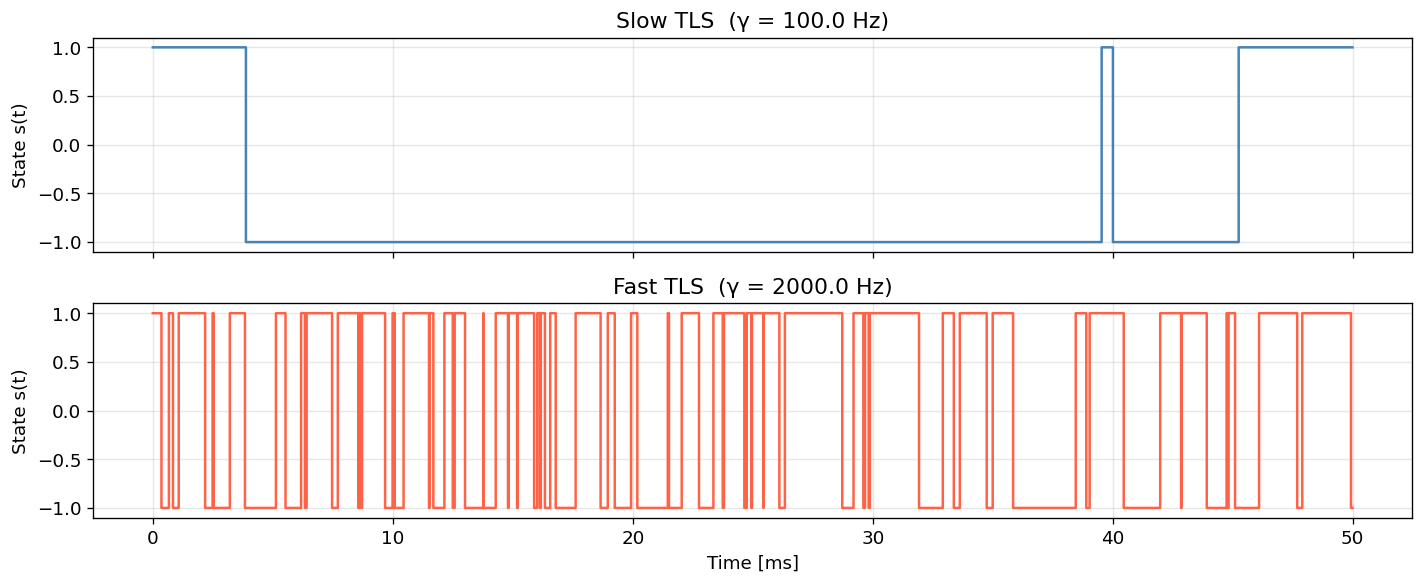

In [13]:
gamma_slow = 100.0 # [Hz]
gamma_fast = 2000.0  # [Hz]

rts_slow = simulate_single_tls(gamma_slow, dt, N_steps, rng)
rts_fast = simulate_single_tls(gamma_fast, dt, N_steps, rng)

# Plot a short timewindow
window = slice(0, int(0.05 / dt)) # first 50 ms

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].step(t[window]*1e3, rts_slow[window], where='post', color='steelblue')
axes[0].set_ylabel('State s(t)')
axes[0].set_title(f'Slow TLS  (γ = {gamma_slow} Hz)')
axes[1].step(t[window]*1e3, rts_fast[window], where='post', color='tomato')
axes[1].set_ylabel('State s(t)')
axes[1].set_title(f'Fast TLS  (γ = {gamma_fast} Hz)')
axes[1].set_xlabel('Time [ms]')
plt.tight_layout()
plt.show()

---
### 2.3. Many-TLS Simulation → 1/f Noise

Assign switching rates **log-uniformly** across many decades:
$$\gamma_i \in [\gamma_{\min}, \gamma_{\max}] \quad (\text{log-uniform})$$

The superposition of many Lorentzians → **1/f spectrum**.

In [15]:
def simulate_many_tls_vectorized(gammas, delta_fs, dt, N_steps, rng):
    N_TLS = len(gammas)
    ps    = gammas * dt # flip probabilities

    states = np.random.choice([-1, 1], size=N_TLS)  # choose initial states (±1)

    delta_f_total = np.zeros(N_steps, dtype=np.float32)

    BATCH = 1000   
    for start in range(0, N_steps, BATCH):
        end   = min(start + BATCH, N_steps)
        B     = end - start

        r = rng.random((B, N_TLS), dtype=np.float32)
        for b in range(B):
            flips = r[b] < ps          
            states[flips] *= -1
            delta_f_total[start + b] = np.dot(states, delta_fs)

    return delta_f_total

#### Plot time domain signals with three different TLS population

<>:29: SyntaxWarning: invalid escape sequence '\g'
<>:29: SyntaxWarning: invalid escape sequence '\g'
/var/folders/j0/7qz6hd0n0qj6jmvrmdbkbx5c002g58/T/ipykernel_9265/2887298563.py:29: SyntaxWarning: invalid escape sequence '\g'
  axes[0].set_title(f'Single TLS (Pure RTN, $\gamma$ = {gamma_single} Hz)')


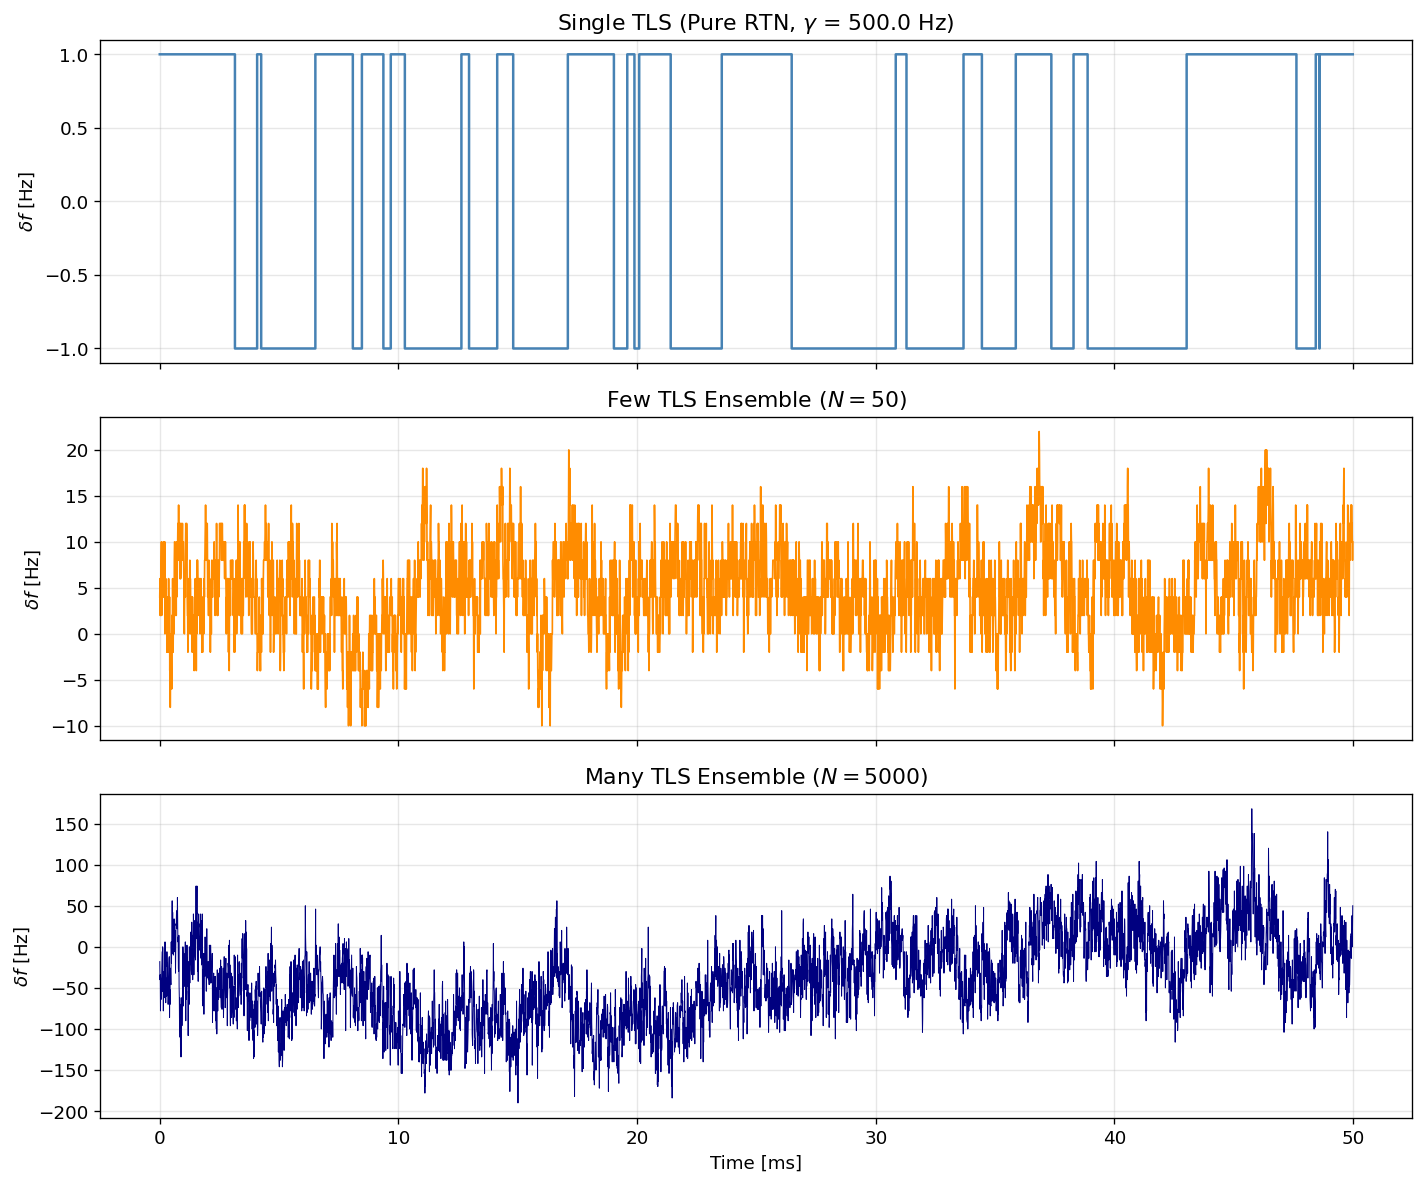

In [19]:
# Parameters
gamma_single = 500.0  # [Hz]
n_few = 50
n_many = 5000

# Generate the three signals
# Single TLS
single_tls = simulate_single_tls(gamma_single, dt, N_steps, rng) * delta_f0

# Few TLS (Log-Uniform)
gammas_few = np.exp(rng.uniform(np.log(gamma_min), np.log(gamma_max), n_few))
dfs_few = np.full(n_few, delta_f0, dtype=np.float32)
few_tls = simulate_many_tls_vectorized(gammas_few, dfs_few, dt, N_steps, rng)

# Many TLS (Log-Uniform)
gammas_many = np.exp(rng.uniform(np.log(gamma_min), np.log(gamma_max), n_many))
dfs_many = np.full(n_many, delta_f0, dtype=np.float32)
many_tls = simulate_many_tls_vectorized(gammas_many, dfs_many, dt, N_steps, rng)

# Combined Plots
window_ms = 50  # first 50 ms
idx_limit = int((window_ms / 1000) / dt)
time_ms = t[:idx_limit] * 1e3

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Plot 1: Single TLS (The Building Block)
axes[0].step(time_ms, single_tls[:idx_limit], where='post', color='steelblue', lw=1.5)
axes[0].set_title(f'Single TLS (Pure RTN, $\gamma$ = {gamma_single} Hz)')
axes[0].set_ylabel(r'$\delta f$ [Hz]')

# Plot 2: Few TLS (The Transition)
axes[1].plot(time_ms, few_tls[:idx_limit], color='darkorange', lw=1)
axes[1].set_title(f'Few TLS Ensemble ($N = {n_few}$)')
axes[1].set_ylabel(r'$\delta f$ [Hz]')

# Plot 3: Many TLS (Emergent 1/f Noise)
axes[2].plot(time_ms, many_tls[:idx_limit], color='navy', lw=0.6)
axes[2].set_title(f'Many TLS Ensemble ($N = {n_many}$)')
axes[2].set_ylabel(r'$\delta f$ [Hz]')
axes[2].set_xlabel('Time [ms]')

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Plot two TLS ensemble with different distribution parameters 

<>:24: SyntaxWarning: invalid escape sequence '\g'
<>:30: SyntaxWarning: invalid escape sequence '\g'
<>:24: SyntaxWarning: invalid escape sequence '\g'
<>:30: SyntaxWarning: invalid escape sequence '\g'
/var/folders/j0/7qz6hd0n0qj6jmvrmdbkbx5c002g58/T/ipykernel_9265/2376297191.py:24: SyntaxWarning: invalid escape sequence '\g'
  axes[0].set_title(f'Identical Ensemble ($N={N_TLS_identical}$, Fixed $\gamma={gamma_fixed}$ Hz)')
/var/folders/j0/7qz6hd0n0qj6jmvrmdbkbx5c002g58/T/ipykernel_9265/2376297191.py:30: SyntaxWarning: invalid escape sequence '\g'
  axes[1].set_title(f'Log-Uniform Ensemble ($N={N_TLS_identical}$, Diverse $\gamma \in [10^{{-3}}, 10^6]$ Hz)')


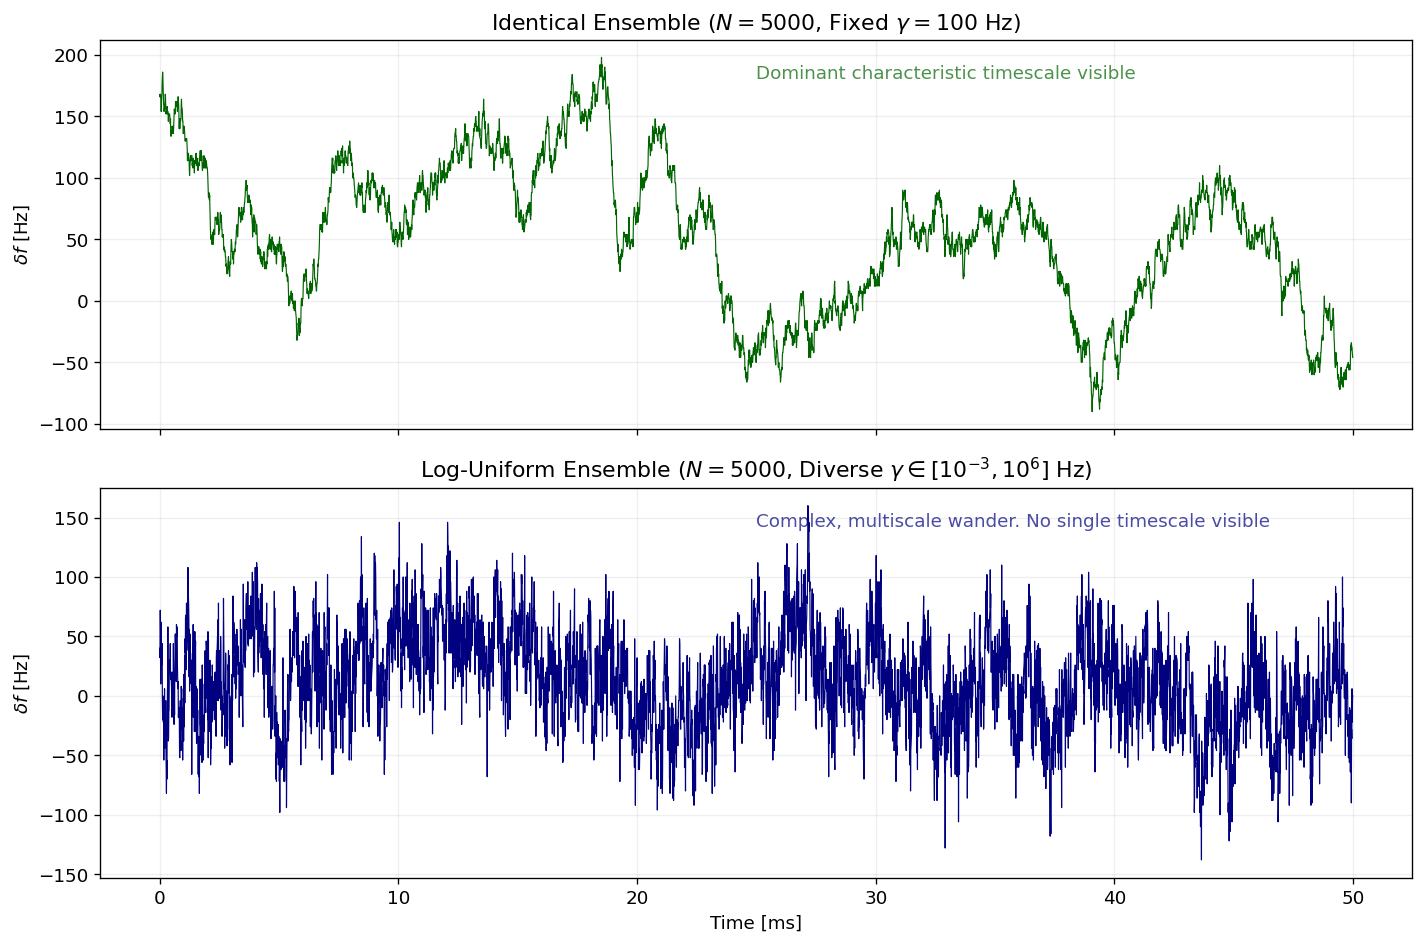

In [42]:
window_ms = 50 # short time window
idx_limit = int((window_ms / 1000) / dt)
time_ms = t[:idx_limit] * 1e3

# Identical Ensemble
N_TLS_identical = 5000
gamma_fixed = 100  # [Hz]
gammas_identical = np.full(N_TLS_identical, gamma_fixed)
delta_fs_identical = np.full(N_TLS_identical, delta_f0, dtype=np.float32)
delta_f_identical = simulate_many_tls_vectorized(gammas_identical, delta_fs_identical, dt, N_steps, rng)
identical_signal = delta_f_identical[:idx_limit]

# Log-Uniform Ensemble
gammas_many_log = np.exp(rng.uniform(np.log(gamma_min), np.log(gamma_max), N_TLS_identical))
dfs_many_log = np.full(N_TLS_identical, delta_f0, dtype=np.float32)
delta_f_log_uniform = simulate_many_tls_vectorized(gammas_many_log, dfs_many_log, dt, N_steps, rng)
log_uniform_signal = delta_f_log_uniform[:idx_limit]

# Combined Plots
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot 1: Identical TLS
axes[0].plot(time_ms, identical_signal, lw=0.7, color='darkgreen')
axes[0].set_title(f'Identical Ensemble ($N={N_TLS_identical}$, Fixed $\gamma={gamma_fixed}$ Hz)')
axes[0].set_ylabel(r'$\delta f$ [Hz]')
axes[0].text(0.5, 0.9, 'Dominant characteristic timescale visible', transform=axes[0].transAxes, color='darkgreen', alpha=0.7)

# Plot 2: Log-Uniform Ensemble
axes[1].plot(time_ms, log_uniform_signal, lw=0.7, color='navy')
axes[1].set_title(f'Log-Uniform Ensemble ($N={N_TLS_identical}$, Diverse $\gamma \in [10^{{-3}}, 10^6]$ Hz)')
axes[1].set_ylabel(r'$\delta f$ [Hz]')
axes[1].set_xlabel('Time [ms]')
axes[1].text(0.5, 0.9, 'Complex, multiscale wander. No single timescale visible', transform=axes[1].transAxes, color='navy', alpha=0.7)

for ax in axes:
    ax.grid(True, which='both', alpha=0.2)
   
plt.tight_layout()
plt.show()

---
### 2.4. Add White Noise

<>:22: SyntaxWarning: invalid escape sequence '\d'
<>:22: SyntaxWarning: invalid escape sequence '\d'
/var/folders/j0/7qz6hd0n0qj6jmvrmdbkbx5c002g58/T/ipykernel_9265/2394485291.py:22: SyntaxWarning: invalid escape sequence '\d'
  plt.ylabel('$\delta f$ [Hz]')


White noise σ: 1.0 Hz
TLS signal σ: 58.010 Hz
Combined signal σ: 58.016 Hz


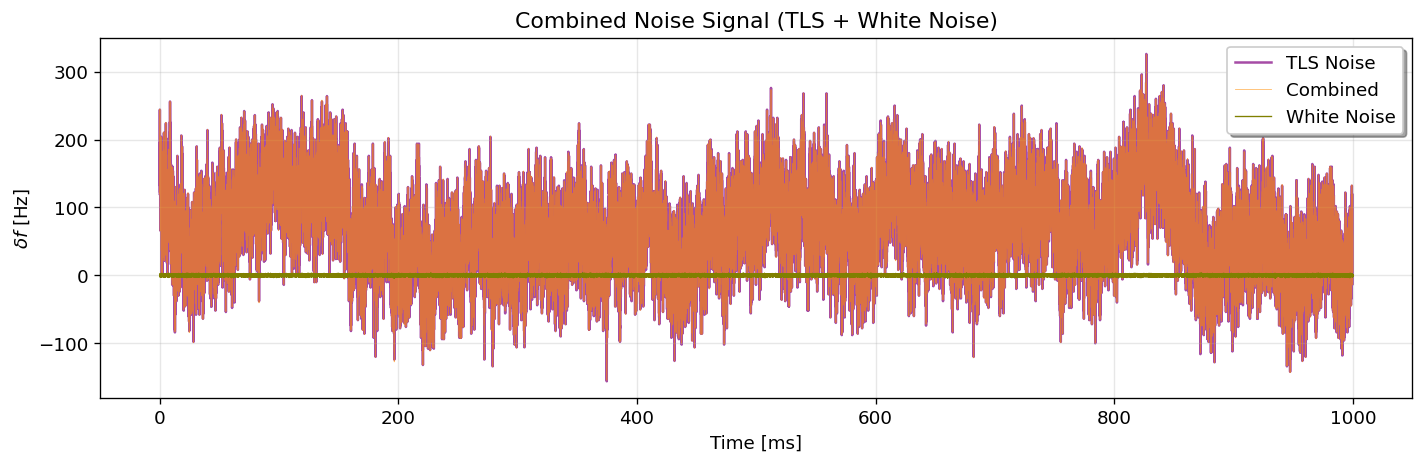

In [36]:
sigma_white = 1.0 # white noise strength
white_noise = rng.normal(0, sigma_white, N_steps).astype(np.float32)

# Log-uniform switching rates
N_TLS = 5000 
gammas = np.exp(rng.uniform(np.log(gamma_min), np.log(gamma_max), N_TLS))
delta_fs = np.full(N_TLS, delta_f0, dtype=np.float32) 
delta_f_tls = simulate_many_tls_vectorized(gammas, delta_fs, dt, N_steps, rng)

delta_f_total = delta_f_tls + white_noise

print(f'White noise σ: {sigma_white} Hz')
print(f'TLS signal σ: {delta_f_tls.std():.3f} Hz')
print(f'Combined signal σ: {delta_f_total.std():.3f} Hz')

plt.figure(figsize=(12, 4))
plt.plot(t[:int(1/dt)]*1e3, delta_f_tls[:int(1/dt)],  color='purple', label='TLS Noise', alpha=0.7, zorder=1)
plt.plot(t[:int(1/dt)]*1e3, delta_f_total[:int(1/dt)], lw=0.5, color='darkorange', label='Combined', alpha=0.6, zorder=2)
plt.plot(t[:int(1/dt)]*1e3, white_noise[:int(1/dt)], color='olive', label='White Noise', lw=0.8, zorder=3)

plt.xlabel('Time [ms]')
plt.ylabel('$\delta f$ [Hz]')
plt.title('Combined Noise Signal (TLS + White Noise)')
plt.legend(loc='upper right', frameon=True, shadow=True)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<>:30: SyntaxWarning: invalid escape sequence '\s'
<>:30: SyntaxWarning: invalid escape sequence '\s'
/var/folders/j0/7qz6hd0n0qj6jmvrmdbkbx5c002g58/T/ipykernel_9265/576170692.py:30: SyntaxWarning: invalid escape sequence '\s'
  ax.set_title(f'{strength}: $\sigma_{{white}}$ = {sigma} Hz', fontweight='bold')


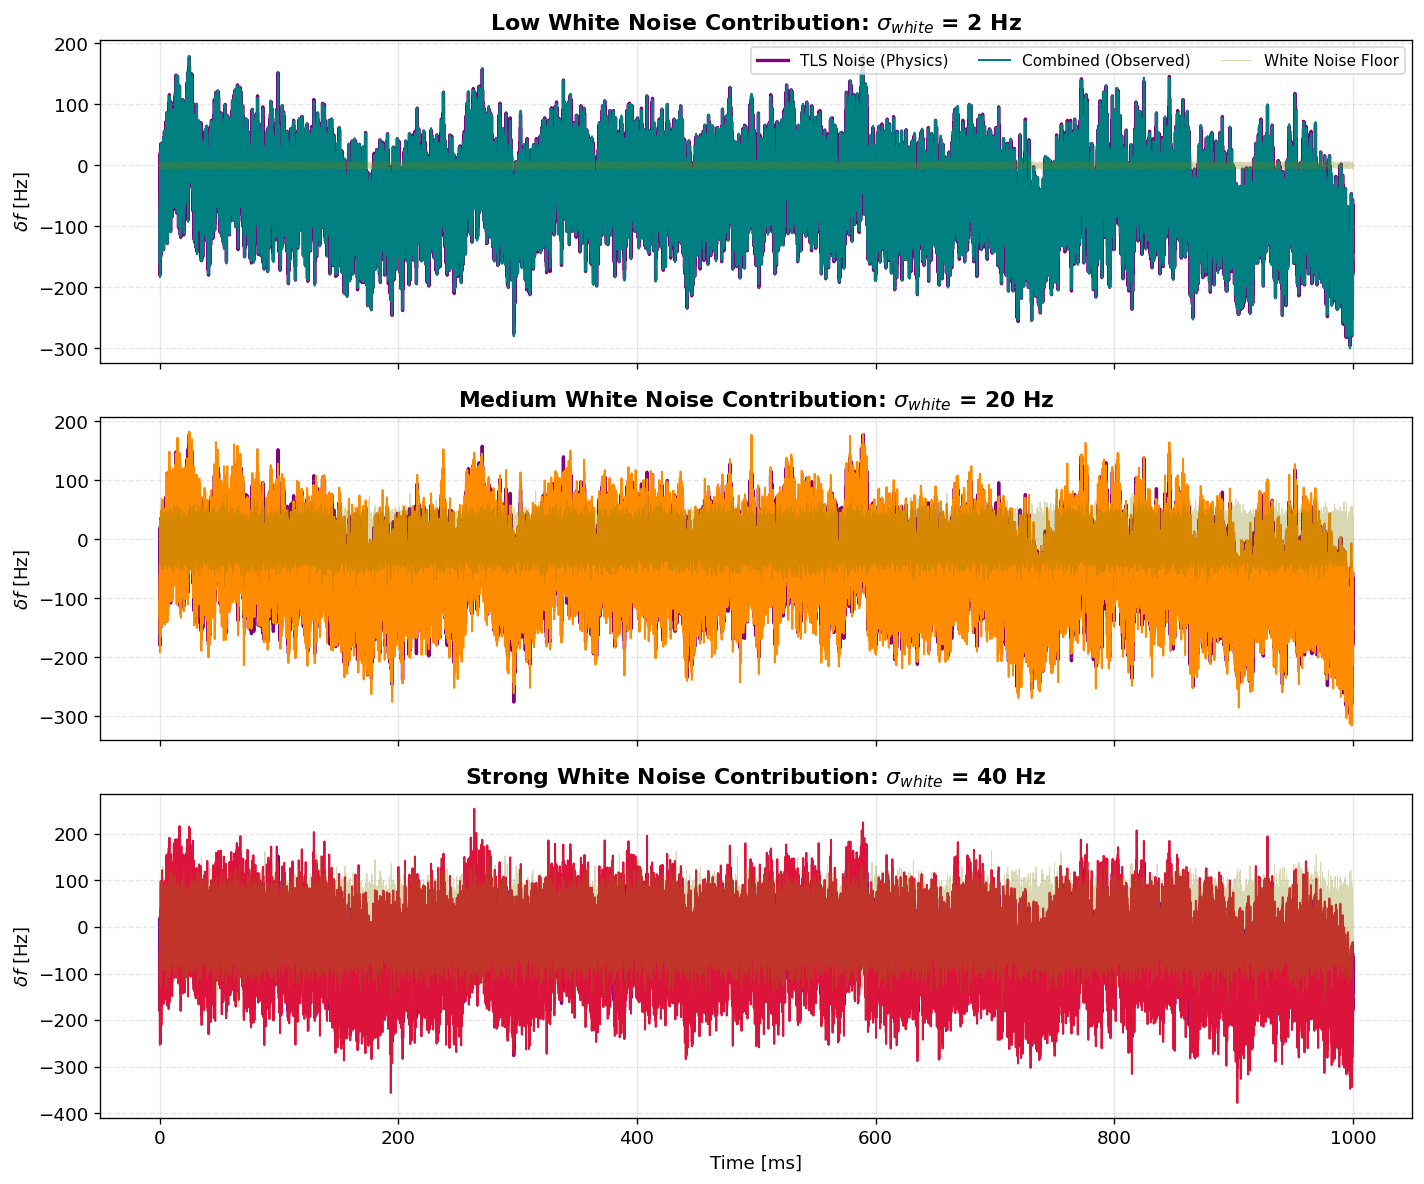

In [ ]:
sigmas = [2, 20, 40]
strengths = ["Low White Noise Contribution", "Medium White Noise Contribution", "Strong White Noise Contribution"]
colors = ['teal', 'darkorange', 'crimson']
window = int(1 / dt)

fig, axes = plt.subplots(len(sigmas), 1, figsize=(12, 10), sharex=True)

for i, (sigma, strength, color) in enumerate(zip(sigmas, strengths, colors)):
    white_noise = rng.normal(0, sigma, N_steps).astype(np.float32)
    delta_f_total = delta_f_tls + white_noise
    
    ax = axes[i]
    
    ax.plot(t[:window]*1e3, delta_f_tls[:window], color='purple', lw=2.0, label='TLS Noise (Physics)', zorder=1)
    ax.plot(t[:window]*1e3, delta_f_total[:window], lw=1.2, color=color, label='Combined (Observed)', zorder=2)
    ax.plot(t[:window]*1e3, white_noise[:window], color='olive', lw=0.6, alpha=0.3, label='White Noise Floor', zorder=3)
    
    ax.set_title(f'{strength}: $\sigma_{{white}}$ = {sigma} Hz', fontweight='bold')
    ax.set_ylabel(r'$\delta f$ [Hz]')
    
    if i == 0:
        ax.legend(loc='upper right', fontsize='small', ncol=3, frameon=True)
    
    ax.grid(axis='y', linestyle='--', alpha=0.3)

axes[-1].set_xlabel('Time [ms]')
plt.tight_layout()
plt.show()

---
## 3. Power Spectral Density (PSD) Analysis

Use Welch's method for a well-averaged, low-variance PSD estimate.

In [38]:
def compute_psd(signal, dt, nperseg=None):
    """Return (freqs, psd) via Welch's method."""
    N = len(signal)
    if nperseg is None:
        nperseg = min(N // 8, 32768)
    freqs, psd = welch(signal.astype(float), fs=1/dt, nperseg=nperseg)
    return freqs[1:], psd[1:] # drop DC

### 3.1. Noise Analysis: Single TLS

In [39]:
def lorentzian_psd(freqs, gamma, delta_f=1.0):
    """Theoretical PSD of a single RTS: S(f) = 4·Δf²·γ / (γ²+(2πf)²)"""
    return 4 * delta_f**2 * gamma / (gamma**2 + (2*np.pi*freqs)**2)

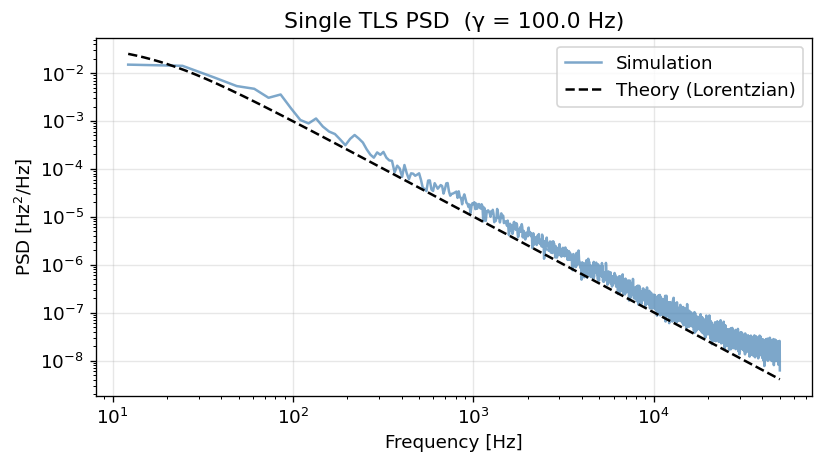

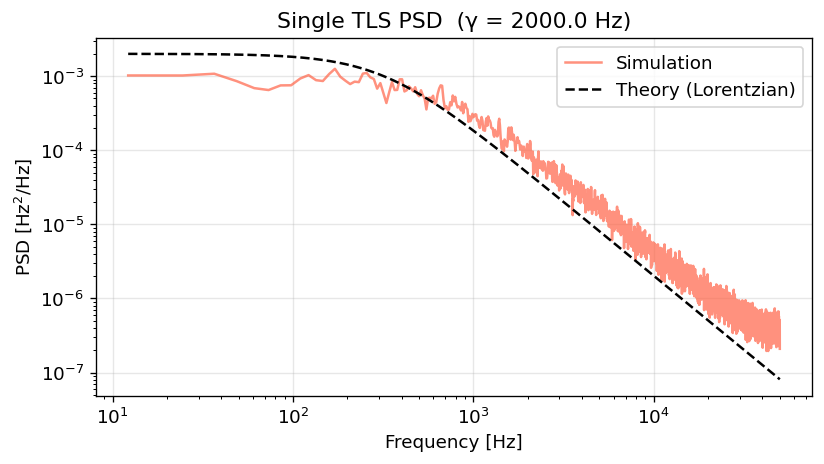

In [ ]:
for gamma_demo, rts_demo, color in [
    (gamma_slow, rts_slow, 'steelblue'),
    (gamma_fast, rts_fast, 'tomato')
]:
    freqs, psd = welch(rts_demo.astype(float), fs=1/dt,
                       nperseg=min(N_steps//8, 8192))
    freqs_th = np.logspace(np.log10(freqs[1]), np.log10(freqs[-1]), 500)

    plt.figure(figsize=(7, 4))
    plt.loglog(freqs[1:], psd[1:], color=color, alpha=0.7, label='Simulation')
    plt.loglog(freqs_th, lorentzian_psd(freqs_th, gamma_demo), 'k--', lw=1.5, label='Theory (Lorentzian)')
    plt.xlabel('Frequency [Hz]')
    plt.ylabel('PSD [Hz$^2$/Hz]')
    plt.title(f'Single TLS PSD  (γ = {gamma_demo} Hz)')
    plt.legend()
    plt.tight_layout()
    plt.show()

### 3.2. Noise Analysis: Different TLS Parameter Distribution

<>:8: SyntaxWarning: invalid escape sequence '\g'
<>:11: SyntaxWarning: invalid escape sequence '\g'
<>:8: SyntaxWarning: invalid escape sequence '\g'
<>:11: SyntaxWarning: invalid escape sequence '\g'
/var/folders/j0/7qz6hd0n0qj6jmvrmdbkbx5c002g58/T/ipykernel_9265/3132669054.py:8: SyntaxWarning: invalid escape sequence '\g'
  plt.loglog(f_ident, psd_ident, label='Identical Ensemble (Fixed $\gamma$)', color='darkgreen', alpha=0.7, lw=1.5)
/var/folders/j0/7qz6hd0n0qj6jmvrmdbkbx5c002g58/T/ipykernel_9265/3132669054.py:11: SyntaxWarning: invalid escape sequence '\g'
  plt.loglog(f_log, psd_log, label='Log-Uniform Ensemble (Diverse $\gamma$)', color='navy', alpha=0.8, lw=1.5)


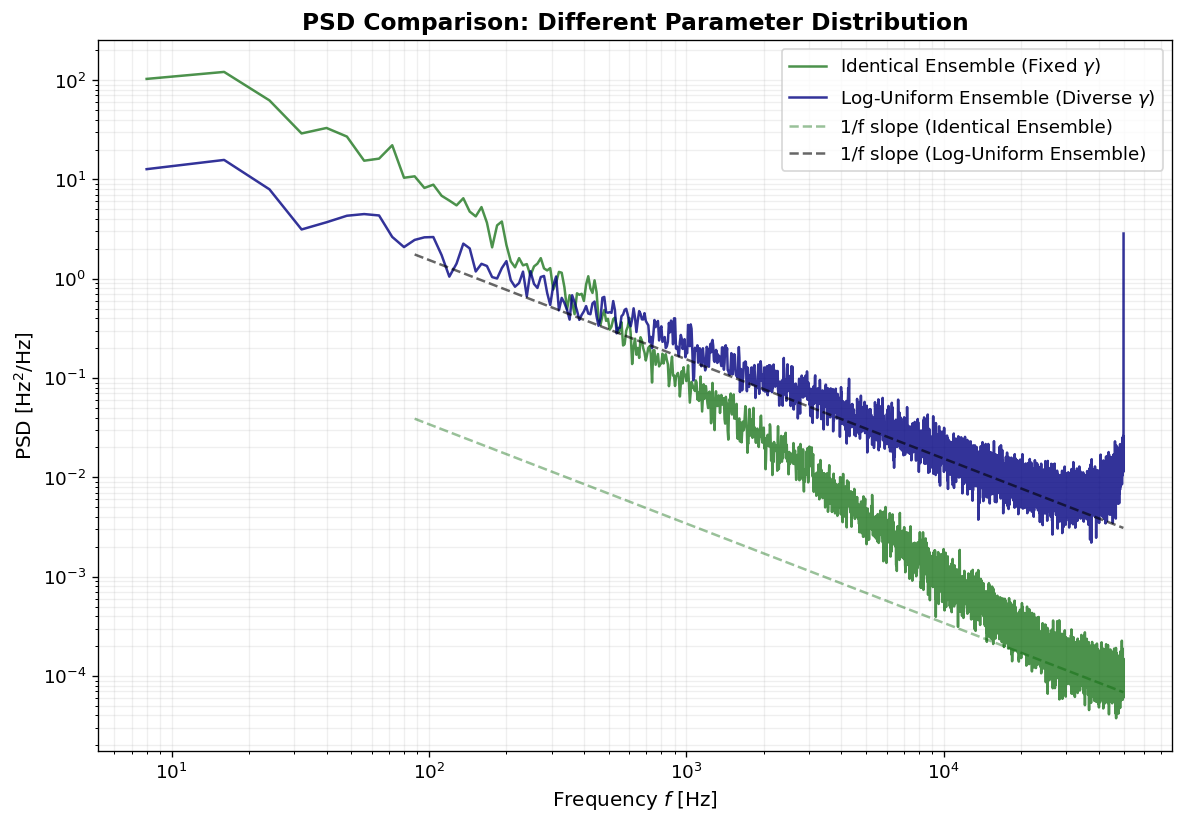

In [46]:
# Compute PSDs
f_ident, psd_ident = compute_psd(delta_f_identical, dt)
f_log, psd_log = compute_psd(delta_f_log_uniform, dt)

plt.figure(figsize=(10, 7))

# Plot Identical Ensemble PSD
plt.loglog(f_ident, psd_ident, label='Identical Ensemble (Fixed $\gamma$)', color='darkgreen', alpha=0.7, lw=1.5)

# Plot Log-Uniform Ensemble PSD
plt.loglog(f_log, psd_log, label='Log-Uniform Ensemble (Diverse $\gamma$)', color='navy', alpha=0.8, lw=1.5)

# Plot theoretical 1/f
f_ref = np.logspace(np.log10(f_log[10]), np.log10(f_log[-10]), 100)
slope_log = (psd_log[len(psd_log)//4]) * (f_log[len(psd_log)//4] / f_ref)
slope_ident = (psd_ident[len(psd_ident)//2]) * (f_ident[len(psd_ident)//2] / f_ref)

plt.loglog(f_ref, slope_ident, '--', color='darkgreen', alpha=0.4, label='1/f slope (Identical Ensemble)')
plt.loglog(f_ref, slope_log, '--k', alpha=0.6, label='1/f slope (Log-Uniform Ensemble)')

plt.title('PSD Comparison: Different Parameter Distribution', fontweight='bold', fontsize=14)
plt.xlabel('Frequency $f$ [Hz]', fontsize=12)
plt.ylabel('PSD [Hz$^2$/Hz]', fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend(frameon=True, fontsize='medium')
plt.tight_layout()
plt.show()

### 3.3. Noise Analysis: Different White Noise Contribution

<>:40: SyntaxWarning: invalid escape sequence '\s'
<>:40: SyntaxWarning: invalid escape sequence '\s'
/var/folders/j0/7qz6hd0n0qj6jmvrmdbkbx5c002g58/T/ipykernel_9265/1084776153.py:40: SyntaxWarning: invalid escape sequence '\s'
  ax.set_title(f'{strength} White Noise ($\sigma={sigma}$)', fontweight='bold')


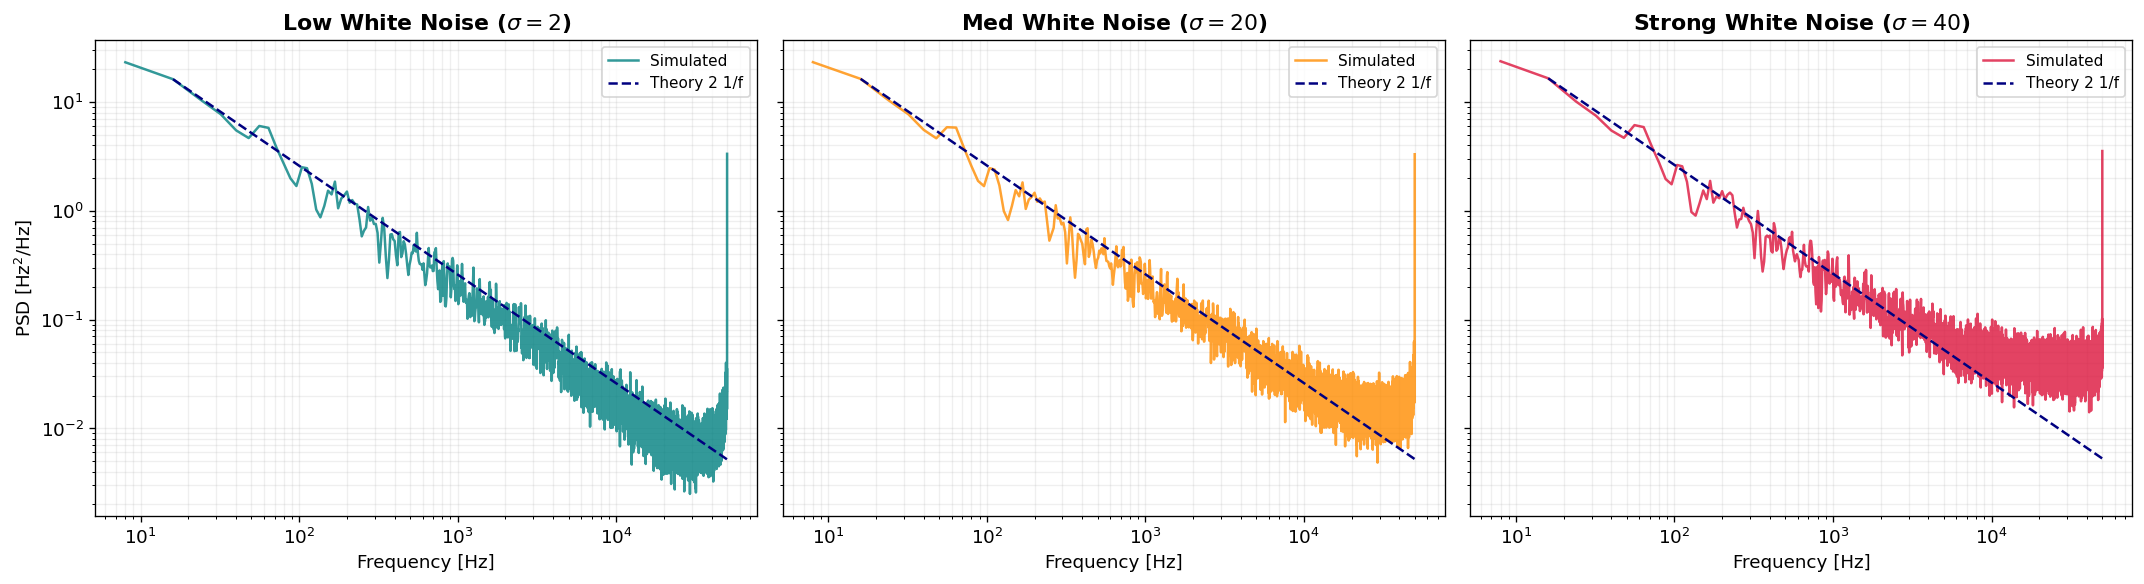

In [ ]:
# Generate the base TLS Signal
N_TLS = 5000
gammas = np.exp(rng.uniform(np.log(gamma_min), np.log(gamma_max), N_TLS))
delta_fs = np.full(N_TLS, delta_f0, dtype=np.float32)

# Simulate the underlying 1/f noise
delta_f_tls = simulate_many_tls_vectorized(gammas, delta_fs, dt, N_steps, rng)

# Parameters for White Noise Contribution
sigmas = [2, 20, 40]
strengths = ["Low", "Med", "Strong"]
colors = ['teal', 'darkorange', 'crimson']
saved_signals = {}

# Compute and plot PSDs
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, (sigma, strength) in enumerate(zip(sigmas, strengths)):
    # Add varying levels of white noise
    white_noise = rng.normal(0, sigma, N_steps).astype(np.float32)
    combined_signal = delta_f_tls + white_noise
    
    ax = axes[i]
    
    # Compute PSDs
    freqs, psd = compute_psd(combined_signal, dt)
    
    # Plot simulated PSDs
    ax.loglog(freqs[:-1], psd[:-1], color=colors[i], alpha=0.8, label='Simulated')
    
    # Plot theoretical 1/f behavior
    f_ref = np.linspace(freqs[1], freqs[-1], 100)
    ax.loglog(f_ref, f_ref**-1 * psd[1] * freqs[1], linestyle="--", color='navy', label='Theory 2 1/f')
    
    ax.set_title(f'{strength} White Noise ($\sigma={sigma}$)', fontweight='bold')
    ax.set_xlabel('Frequency [Hz]')
    if i == 0:
        ax.set_ylabel('PSD [Hz$^2$/Hz]')
    
    ax.grid(True, which="both", ls="-", alpha=0.2)
    ax.legend(fontsize='small')

plt.tight_layout()
plt.show()

### 3.2. Noise Analysis: Different TLS population

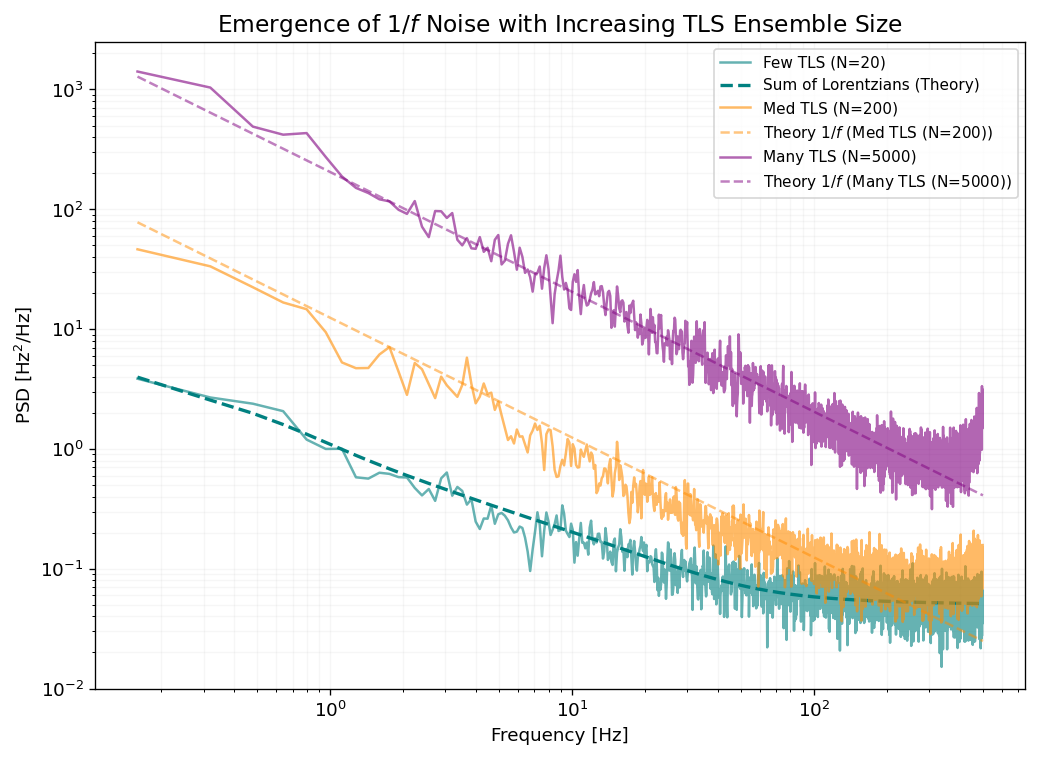

In [ ]:
# Simulation
n_tls_values = [20, 200, 5000]
labels = [f"Few TLS (N={n_tls_values[0]})", 
          f"Med TLS (N={n_tls_values[1]})", 
          f"Many TLS (N={n_tls_values[2]})"]
sigma_fixed = 5  
saved_signals_tls = {}
few_tls_gammas = None

for n_val, label in zip(n_tls_values, labels):
    gammas_batch = np.exp(rng.uniform(np.log(gamma_min), np.log(gamma_max), n_val))
    delta_fs_batch = np.full(n_val, delta_f0, dtype=np.float32)
    
    if n_val == n_tls_values[0]:
        few_tls_gammas = gammas_batch
        
    tls_signal = simulate_many_tls_vectorized(gammas_batch, delta_fs_batch, dt, N_steps, rng)
    white_noise = rng.normal(0, sigma_fixed, N_steps).astype(np.float32)
    saved_signals_tls[label] = tls_signal + white_noise

plt.figure(figsize=(10, 7))
colors_psd = ['teal', 'darkorange', 'purple']

for i, (label, signal) in enumerate(saved_signals_tls.items()):
    freqs, psd = compute_psd(signal, dt)
    
    # Plot the simulated data
    plt.loglog(freqs[:-10], psd[:-10], color=colors_psd[i], alpha=0.6, label=label, lw=1.5)
    
    if i == 0:
        # Lorentzian plot
        total_lorentzian = np.zeros_like(freqs)
        for g in few_tls_gammas:
            A = (4 * delta_f0**2) / g
            total_lorentzian += A / (1 + (2 * np.pi * freqs / g)**2)
        
        # Add white noise floor to theory
        theory_few = total_lorentzian + (2 * dt * sigma_fixed**2)
        plt.loglog(freqs, theory_few, linestyle='--', color=colors_psd[i], lw=2, label='Sum of Lorentzians (Theory)')
    
    else:
        # Theory 1/f
        anchor_freq = freqs[10] 
        anchor_psd = psd[10]
        one_over_f = anchor_psd * (anchor_freq / freqs)
        plt.loglog(freqs, one_over_f, linestyle='--', color=colors_psd[i], alpha=0.5, label=f'Theory $1/f$ ({label})')

plt.title('Emergence of $1/f$ Noise with Increasing TLS Ensemble Size', fontsize=14)
plt.xlabel('Frequency [Hz]')
plt.ylabel('PSD [Hz$^2$/Hz]')
plt.legend(fontsize='small', loc='upper right')
plt.grid(True, which="both", ls="-", alpha=0.1)
plt.ylim(bottom=1e-2)
plt.show()